### Part 1: Capacitors

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

a = 71.9999994018466
b = 664.8000001301561


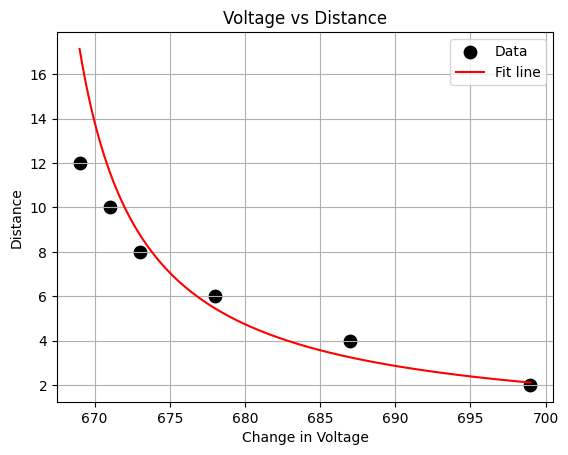

In [2]:
# Voltage is propertional to 1 over distance
def voltage_model(d, a, b):
    return b + a/d

voltages = np.array([699, 687, 678, 673, 671, 669])
distances = np.array([2, 4, 6, 8, 10, 12])

# fit V = b + a/d to get coefficients
popt, pcov = curve_fit(voltage_model, distances, voltages)

a_fit, b_fit = popt
print("a =", a_fit)
print("b =", b_fit)

# Now use coefficients to model the relationship between voltage and distance
def distance_from_voltage(V):
    return a_fit / (V - b_fit)

# smooth voltage values for plotting
V_smooth = np.linspace(min(voltages), max(voltages), 300)
d_pred = distance_from_voltage(V_smooth)

# plot
plt.scatter(voltages, distances, color="black", s=80, label="Data")
plt.plot(V_smooth, d_pred, color="red", label="Fit line")

plt.xlabel("Change in Voltage")
plt.ylabel("Distance")
plt.title("Voltage vs Distance")
plt.legend()
plt.grid(True)

plt.show()

### Part 2: Photoresistors

In [95]:
voltages = np.array([151, 330, 523, 744, 874, 1080])
distances_part2 = np.array([2, 4, 6, 8, 10, 12])

coefficients_part2 = np.polyfit(voltages, distances_part2, 1)
m_part2, b_part2 = coefficients_part2[0], coefficients_part2[1]

print(f"Part 2 Linear fit: d = {m_part2:.4f} * V + {b_part2:.4f}")
print(f"Slope (m): {m_part2:.4f}")
print(f"Intercept (b): {b_part2:.4f}")

d_pred_part2 = np.polyval(coefficients_part2, voltages)
ss_res_part2 = np.sum((distances_part2 - d_pred_part2) ** 2)
ss_tot_part2 = np.sum((distances_part2 - np.mean(distances_part2)) ** 2)
r_squared_part2 = 1 - (ss_res_part2 / ss_tot_part2)
print(f"R-squared: {r_squared_part2:.6f}")

Part 2 Linear fit: d = 0.0107 * V + 0.3721
Slope (m): 0.0107
Intercept (b): 0.3721
R-squared: 0.997177


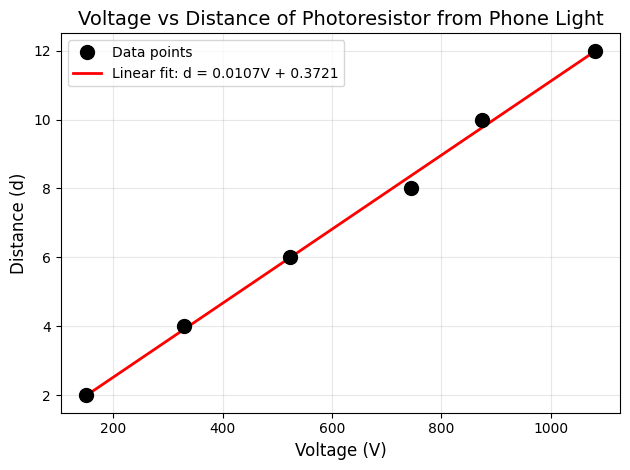

In [96]:
# Plot Part 2 with voltage on x-axis, distance on y-axis
v_fit_part2 = np.linspace(voltages.min(), voltages.max(), 100)
d_fit_part2 = np.polyval(coefficients_part2, v_fit_part2)

plt.title("Voltage vs Distance of Photoresistor from Phone Light", fontsize=14)
plt.xlabel("Voltage (V)", fontsize=12)
plt.ylabel("Distance (d)", fontsize=12)
plt.plot(voltages, distances_part2, 'ko', label='Data points', markersize=10, zorder=5)
plt.plot(v_fit_part2, d_fit_part2, 'r-', label=f'Linear fit: d = {m_part2:.4f}V + {b_part2:.4f}', linewidth=2)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()